# Customer CLV Prediction
Production-ready customer lifetime value notebook


## 1. Business Problem
Estimate the future revenue expected from each customer using their past purchasing behaviour.


## 2. Business Objectives
- Estimate expected future revenue
- Identify high-value customers
- Create VIP customer segments


## 3. ML Workflow
Business Understanding → Feature Engineering → Regression Modeling → Evaluation → Customer Segmentation


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap
import joblib


## 4. Load Dataset

In [2]:

from pathlib import Path

DATA_PATH = Path("../data/processed/master_df.parquet")
master_df = pd.read_parquet(DATA_PATH)

master_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


## 5. Dataset Overview

In [3]:
master_df.shape
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 49 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_status                   category      
 3   order_purchase_timestamp       datetime64[ns]
 4   order_approved_at              datetime64[ns]
 5   order_delivered_carrier_date   datetime64[ns]
 6   order_delivered_customer_date  datetime64[ns]
 7   order_estimated_delivery_date  datetime64[ns]
 8   customer_unique_id             object        
 9   customer_name                  object        
 10  customer_gender                category      
 11  customer_age                   int8          
 12  customer_zip_code_prefix       int32         
 13  customer_city                  object        
 14  customer_state                 category      
 15  customer_segmen

## 6. Data Quality Check

In [4]:
pd.DataFrame({
    "dtype": master_df.dtypes,
    "missing": master_df.isna().sum(),
    "missing_%": (master_df.isna().mean()*100).round(2)
}).sort_values("missing_%", ascending=False)

,dtype,missing,missing_%
order_delivered_customer_date,datetime64[ns],167729,6.63
order_delivered_carrier_date,datetime64[ns],167729,6.63
review_score,float32,167729,6.63
review_comment_title,object,167729,6.63
review_comment_message,object,167729,6.63
review_id,object,167729,6.63
review_creation_date,datetime64[ns],167729,6.63
review_answer_timestamp,datetime64[ns],167729,6.63
order_id,object,0,0.00
customer_name,object,0,0.00


## 7. Missing Values Handling

In [5]:
master_df["delivery_delay"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_estimated_delivery_date"]
).dt.days

master_df["delivery_time"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_purchase_timestamp"]
).dt.days

customer_features = (
    master_df.groupby("customer_unique_id")
    .agg(
        Avg_Delivery_Delay=("delivery_delay", "mean"),
        Avg_Delivery_Time=("delivery_time", "mean")
    )
)


customer_features["Avg_Delivery_Delay"] = (
    customer_features["Avg_Delivery_Delay"].fillna(0)
)

customer_features["Avg_Delivery_Time"] = (
    customer_features["Avg_Delivery_Time"].fillna(0)
)


customer_review = (
    master_df.groupby("customer_unique_id")
    .agg(
        Avg_Review_Score=("review_score", "mean")
    )
)

customer_review["Avg_Review_Score"] = (
    customer_review["Avg_Review_Score"]
    .fillna(customer_review["Avg_Review_Score"].mean())
)

customer_review["Avg_Review_Score"] = (
    customer_review["Avg_Review_Score"].fillna(0)
)

### Missing Value Handling

The missing values are limited to delivery and customer review information (approximately 6.63% of records). These missing values are business-related rather than data quality issues.

- Delivery dates are unavailable for cancelled, unavailable, or undelivered orders.
- Customer reviews are optional, so some orders have no review information.

Instead of imputing values in the original dataset, missing values are handled during customer-level feature engineering:

- Delivery-based features are calculated only for completed deliveries, and customers with no delivery history receive a value of 0.
- Average review scores are computed per customer, and customers without reviews are assigned the overall average review score.

This approach preserves the integrity of the original dataset while producing a complete feature matrix for machine learning.

## 8. Duplicate Analysis

In [6]:
print("Duplicate rows:", master_df.duplicated().sum())

Duplicate rows: 0


## 9. CLV Definition


### Business Definition

Customer lifetime value (CLV) is estimated here as the **revenue a customer will generate in the next 90 days**.

- Historical period: all purchases before the final 90 days of available data
- Prediction period: the final 90 days of available data
- Target: total payment value in the prediction period

Customers with no purchases in the prediction period have future revenue of 0. This gives the model a realistic revenue target while using only information available before the prediction period.


## 10. Customer Feature Engineering


In [7]:
# Customer-level CLV features and future-revenue target
reference_date = master_df["order_purchase_timestamp"].max()
cutoff_date = reference_date - pd.Timedelta(days=90)

history_df = master_df[master_df["order_purchase_timestamp"] < cutoff_date].copy()
future_df = master_df[master_df["order_purchase_timestamp"] >= cutoff_date].copy()

history_df["Delivery_Delay"] = (
    history_df["order_delivered_customer_date"] - history_df["order_estimated_delivery_date"]
).dt.days

customer_df = (
    history_df.groupby("customer_unique_id")
    .agg(
        Total_Orders=("order_id", "nunique"),
        Total_Spend=("payment_value", "sum"),
        Average_Order_Value=("payment_value", "mean"),
        Last_Purchase=("order_purchase_timestamp", "max"),
        Avg_Review_Score=("review_score", "mean"),
        Avg_Delivery_Delay=("Delivery_Delay", "mean"),
        Avg_Discount=("discount_rate", "mean"),
        Avg_Freight=("freight_value", "mean"),
        Payment_Method=("payment_type", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        Product_Diversity=("product_category_name", "nunique")
    )
    .reset_index()
)

future_revenue = (
    future_df.groupby("customer_unique_id")["payment_value"]
    .sum()
    .rename("Expected_Future_Revenue")
    .reset_index()
)

customer_df = customer_df.merge(future_revenue, on="customer_unique_id", how="left")
customer_df["Expected_Future_Revenue"] = customer_df["Expected_Future_Revenue"].fillna(0)
customer_df["Recency"] = (cutoff_date - customer_df["Last_Purchase"]).dt.days
customer_df["Avg_Review_Score"] = customer_df["Avg_Review_Score"].fillna(customer_df["Avg_Review_Score"].mean())
customer_df["Avg_Delivery_Delay"] = customer_df["Avg_Delivery_Delay"].fillna(0)

print("Historical customers:", customer_df.shape[0])
print("Prediction window starts:", cutoff_date.date())
customer_df.head()


Historical customers: 273833
Prediction window starts: 2025-10-02


,customer_unique_id,Total_Orders,Total_Spend,Average_Order_Value,Last_Purchase,Avg_Review_Score,Avg_Delivery_Delay,Avg_Discount,Avg_Freight,Payment_Method,Product_Diversity,Expected_Future_Revenue,Recency
0,00000ce0-2e08-4b89-ba86-0c8698b2d4fb,2,1293.010010,646.505005,2025-04-28 09:45:33,5.000000,-2.0000,0.000000,106.354996,bank_transfer,2,0.000000,157
1,00004453-ecfa-4c25-94f1-0004cc58286f,2,2119.609863,529.902466,2024-05-11 11:31:12,5.000000,-2.0000,0.055000,98.607498,boleto,4,0.000000,509
2,000076de-9d04-4ae8-af41-2f8caf66c899,5,35451.160156,2215.697510,2025-08-17 11:44:11,3.500000,-0.6875,0.013750,104.887497,credit_card,5,0.000000,46
3,00008df1-f9ce-487d-b5a6-68e6992e025a,6,12694.430664,906.745056,2025-05-31 17:41:26,3.571429,-1.0000,0.018571,148.145721,credit_card,6,11054.550781,124
4,00009e20-cfbd-4b4b-b304-38868364135e,2,5710.690430,1142.138062,2025-09-03 08:42:13,2.600000,2.2000,0.000000,77.599998,paypal,4,0.000000,29


## 11. Correlation Analysis


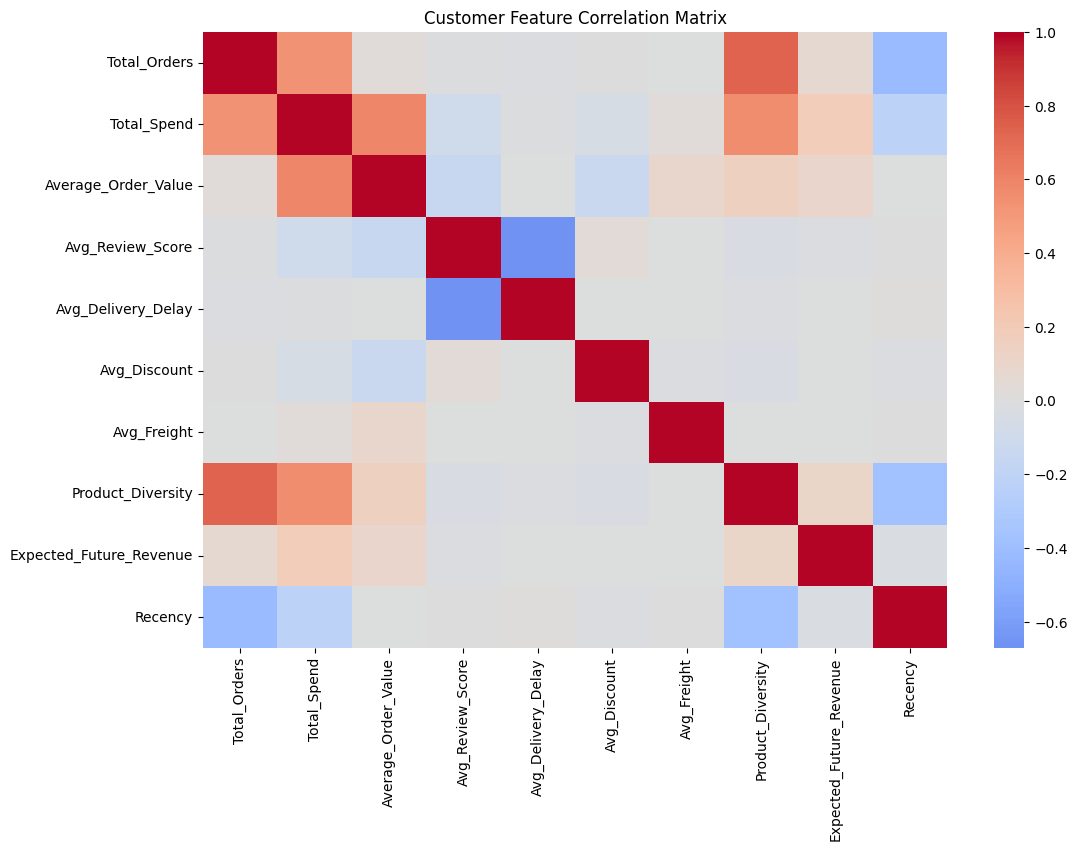

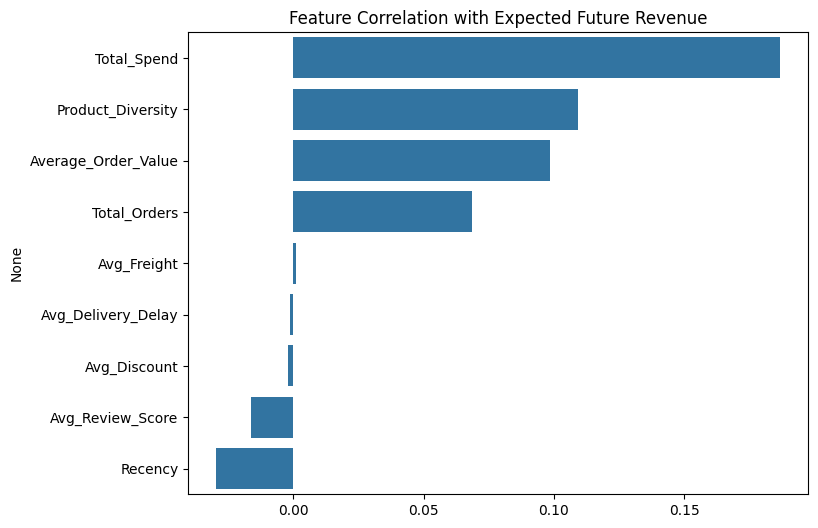

,Correlation
Total_Spend,0.186685
Product_Diversity,0.109318
Average_Order_Value,0.098511
Total_Orders,0.068671
Avg_Freight,0.001297
Avg_Delivery_Delay,-0.001112
Avg_Discount,-0.001999
Avg_Review_Score,-0.016255
Recency,-0.029441


In [8]:
# Correlation with expected future revenue
numeric_df = customer_df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Customer Feature Correlation Matrix")
plt.show()

clv_corr = corr_matrix["Expected_Future_Revenue"].drop("Expected_Future_Revenue").sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=clv_corr.values, y=clv_corr.index)
plt.title("Feature Correlation with Expected Future Revenue")
plt.show()
display(clv_corr.to_frame("Correlation"))


## 12. Target Distribution


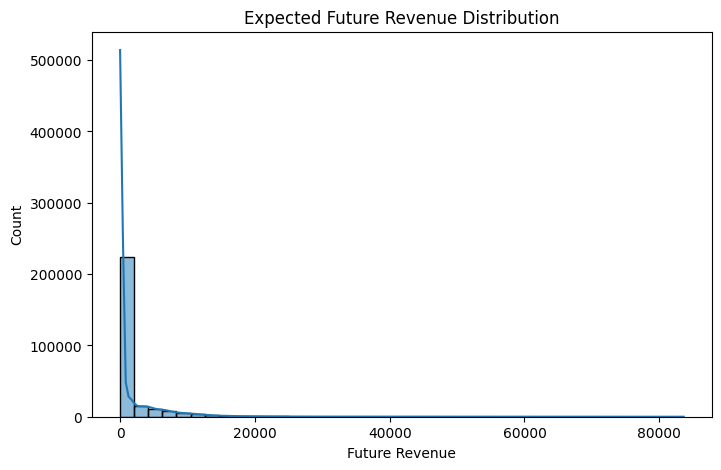

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(customer_df["Expected_Future_Revenue"], bins=40, kde=True)
plt.title("Expected Future Revenue Distribution")
plt.xlabel("Future Revenue")
plt.show()


## 13. Train/Test Split


In [10]:
# Last_Purchase is a date and customer ID is an identifier, so both are excluded.
X = customer_df.drop(columns=["customer_unique_id", "Last_Purchase", "Expected_Future_Revenue"])
y = customer_df["Expected_Future_Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (219066, 10)
Testing Shape: (54767, 10)


## 14. Pipeline-based Preprocessing


In [11]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))


Numerical Columns: 9
Categorical Columns: 1


## 15. Linear Regression


In [12]:
# Linear Regression Pipeline
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
linear_pipeline.fit(X_train, y_train)

# Predictions
linear_pred = linear_pipeline.predict(X_test)

# Evaluation
print("=" * 60)
print("Linear Regression Results")
print("=" * 60)
print(f"MAE  : {mean_absolute_error(y_test, linear_pred):.2f}")
print(f"RMSE : {mean_squared_error(y_test, linear_pred) ** 0.5:.2f}")
print(f"R2   : {r2_score(y_test, linear_pred):.4f}")


Linear Regression Results
MAE  : 2270.43
RMSE : 4079.09
R2   : 0.0390


## 16. Random Forest Regressor


In [13]:
# Random Forest Regressor Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_estimators=200))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("=" * 60)
print("Random Forest Regressor Results")
print("=" * 60)
print(f"MAE  : {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"RMSE : {mean_squared_error(y_test, rf_pred) ** 0.5:.2f}")
print(f"R2   : {r2_score(y_test, rf_pred):.4f}")


Random Forest Regressor Results
MAE  : 2420.03
RMSE : 4123.51
R2   : 0.0180


## 17. XGBoost Regressor


In [14]:
# XGBoost Regressor Pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=4))
])
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

print("=" * 60)
print("XGBoost Regressor Results")
print("=" * 60)
print(f"MAE  : {mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"RMSE : {mean_squared_error(y_test, xgb_pred) ** 0.5:.2f}")
print(f"R2   : {r2_score(y_test, xgb_pred):.4f}")


XGBoost Regressor Results
MAE  : 2262.04
RMSE : 4062.05
R2   : 0.0470


## 18. LightGBM Regressor


In [15]:
# LightGBM Regressor Pipeline
lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LGBMRegressor(random_state=42, verbosity=-1))
])
lgbm_pipeline.fit(X_train, y_train)
lgbm_pred = lgbm_pipeline.predict(X_test)

print("=" * 60)
print("LightGBM Regressor Results")
print("=" * 60)
print(f"MAE  : {mean_absolute_error(y_test, lgbm_pred):.2f}")
print(f"RMSE : {mean_squared_error(y_test, lgbm_pred) ** 0.5:.2f}")
print(f"R2   : {r2_score(y_test, lgbm_pred):.4f}")


LightGBM Regressor Results
MAE  : 2261.60
RMSE : 4064.31
R2   : 0.0460


## 19. Cross Validation


In [16]:
# Cross validation for all regression models
models = {
    "Linear Regression": linear_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, model in models.items():
    scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error")
    
    cv_results.append({"Model": name, "CV MAE Mean": scores.mean(), "CV MAE Std": scores.std()})

cv_results = pd.DataFrame(cv_results).sort_values("CV MAE Mean")
best_model_name = cv_results.iloc[0]["Model"]
display(cv_results)
print(f"Best model by CV MAE: {best_model_name}")


,Model,CV MAE Mean,CV MAE Std
2,XGBoost,2228.591406,10.139271
3,LightGBM,2229.691445,9.319216
0,Linear Regression,2235.904113,9.070073
1,Random Forest,2390.569113,9.382310


Best model by CV MAE: XGBoost


## 20. Hyperparameter Tuning


In [18]:
# Tune the model with the lowest cross-validation MAE
param_distributions = {
    "Linear Regression": {},
    "Random Forest": {"regressor__n_estimators": [100, 200, 300], "regressor__max_depth": [None, 5, 10]},
    "XGBoost": {"regressor__n_estimators": [100, 200, 300], "regressor__max_depth": [3, 4, 5], "regressor__learning_rate": [0.01, 0.05, 0.1]},
    "LightGBM": {"regressor__n_estimators": [100, 200, 300], "regressor__num_leaves": [15, 31, 63], "regressor__learning_rate": [0.01, 0.05, 0.1]}
}

if best_model_name == "Linear Regression":
    best_pipeline = models[best_model_name]
    best_pipeline.fit(X_train, y_train)
else:
    search = RandomizedSearchCV(models[best_model_name], 
                                param_distributions[best_model_name], 
                                n_iter=5, 
                                scoring="neg_mean_absolute_error", 
                                cv=3, 
                                random_state=42, 
                                n_jobs=-1)
    
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    print("Best parameters:", search.best_params_)

best_pred = best_pipeline.predict(X_test)
print(f"Tuned model: {best_model_name}")
print(f"Test MAE: {mean_absolute_error(y_test, best_pred):.2f}")
print(f"Test RMSE: {mean_squared_error(y_test, best_pred) ** 0.5:.2f}")
print(f"Test R2: {r2_score(y_test, best_pred):.4f}")


Best parameters: {'regressor__n_estimators': 100, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.1}
Tuned model: XGBoost
Test MAE: 2263.06
Test RMSE: 4063.89
Test R2: 0.0462


## 21. Model Comparison Table


In [30]:
model_predictions = {
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    f"Tuned {best_model_name}": best_pred
}

comparison = pd.DataFrame([
    {"Model": name, "MAE": mean_absolute_error(y_test, pred), "RMSE": mean_squared_error(y_test, pred) ** 0.5, "R2": r2_score(y_test, pred)}
    for name, pred in model_predictions.items()
]).sort_values("MAE")
display(comparison)


,Model,MAE,RMSE,R2
3,LightGBM,2261.598367,4064.306439,0.045975
2,XGBoost,2262.039062,4062.053299,0.047032
4,Tuned XGBoost,2263.061279,4063.889885,0.046170
0,Linear Regression,2270.433347,4079.088729,0.039022
1,Random Forest,2420.034702,4123.507966,0.017979


## 22. Actual vs Predicted Revenue


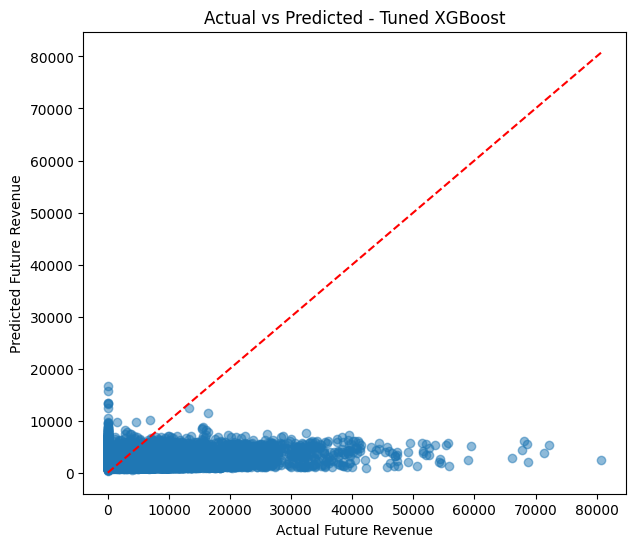

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Future Revenue")
plt.ylabel("Predicted Future Revenue")
plt.title(f"Actual vs Predicted - Tuned {best_model_name}")
plt.show()


## 23. Residual Analysis


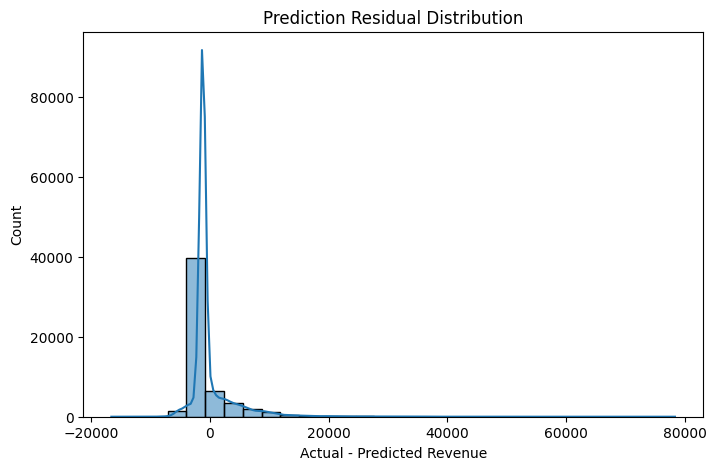

In [21]:
residuals = y_test - best_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Prediction Residual Distribution")
plt.xlabel("Actual - Predicted Revenue")
plt.show()


## 24. Model Performance


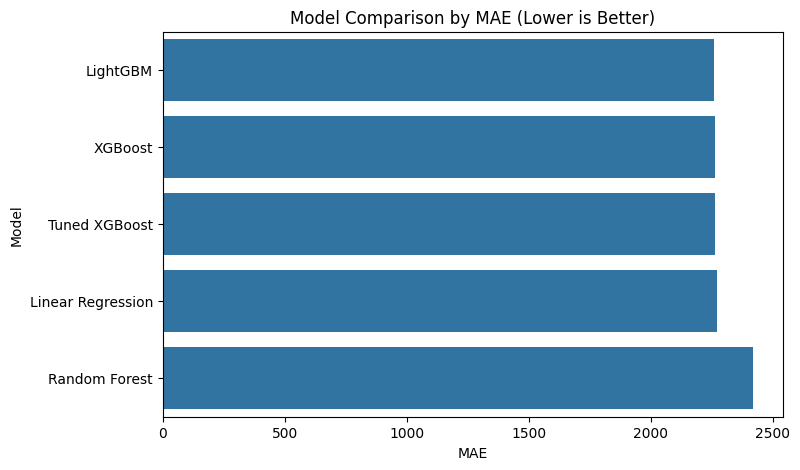

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="MAE", y="Model")
plt.title("Model Comparison by MAE (Lower is Better)")
plt.show()


## 25. Survival Analysis


In [23]:
# Simple customer survival proxy: purchased in the future 90-day window
customer_df["Purchased_In_Next_90_Days"] = (customer_df["Expected_Future_Revenue"] > 0).astype(int)
survival_rate = customer_df["Purchased_In_Next_90_Days"].mean()
print(f"Customer survival rate for the next 90 days: {survival_rate:.2%}")


Customer survival rate for the next 90 days: 29.41%


## 26. Feature Importance


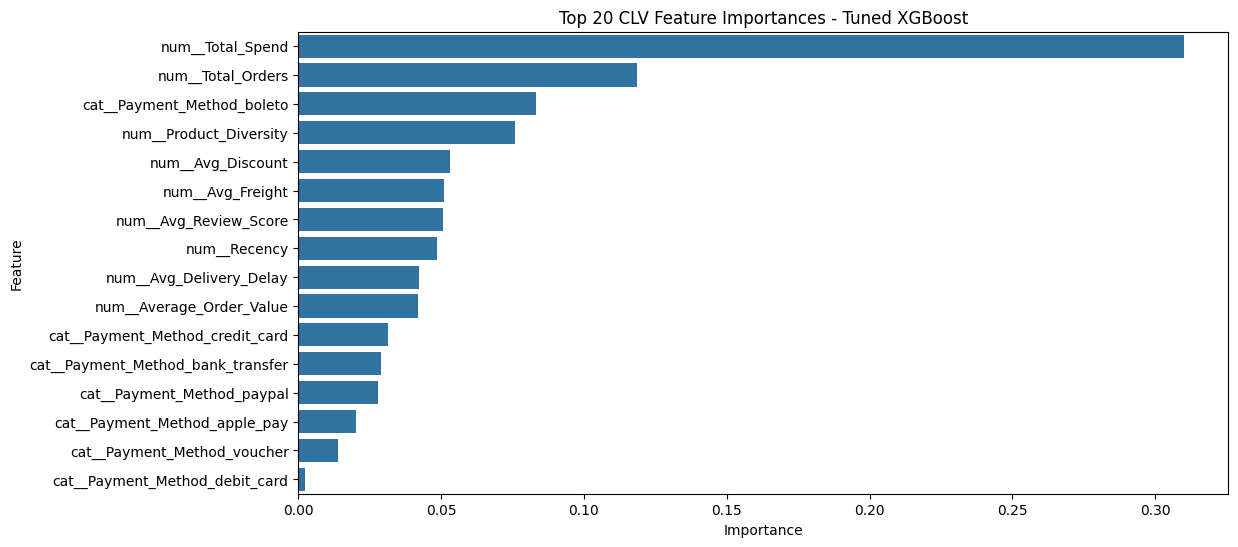

,Feature,Importance
1,num__Total_Spend,0.310158
0,num__Total_Orders,0.118639
11,cat__Payment_Method_boleto,0.083155
7,num__Product_Diversity,0.075851
5,num__Avg_Discount,0.052933
6,num__Avg_Freight,0.051001
3,num__Avg_Review_Score,0.050785
8,num__Recency,0.048572
4,num__Avg_Delivery_Delay,0.042360
2,num__Average_Order_Value,0.041947


In [24]:
best_preprocessor = best_pipeline.named_steps["preprocessor"]
best_regressor = best_pipeline.named_steps["regressor"]
feature_names = best_preprocessor.get_feature_names_out()

if hasattr(best_regressor, "feature_importances_"):
    importance_values = best_regressor.feature_importances_
else:
    importance_values = np.abs(best_regressor.coef_)

feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importance_values}).sort_values("Importance", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title(f"Top 20 CLV Feature Importances - Tuned {best_model_name}")
plt.show()
display(feature_importance)


## 27. SHAP Summary


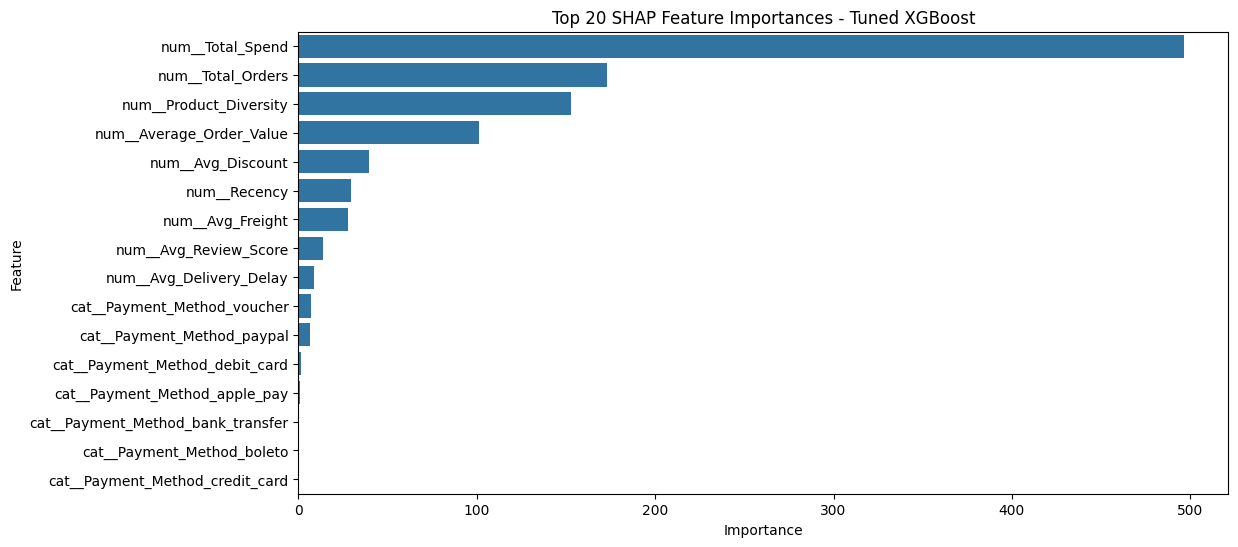

,Feature,Importance
1,num__Total_Spend,496.560883
0,num__Total_Orders,173.277710
7,num__Product_Diversity,153.070038
2,num__Average_Order_Value,101.243912
5,num__Avg_Discount,39.477802
8,num__Recency,29.260504
6,num__Avg_Freight,27.673126
3,num__Avg_Review_Score,14.032625
4,num__Avg_Delivery_Delay,9.001855
15,cat__Payment_Method_voucher,7.150122


In [25]:
shap_data = X_test.sample(min(500, len(X_test)), random_state=42)
shap_features = best_preprocessor.transform(shap_data)
if hasattr(shap_features, "toarray"):
    shap_features = shap_features.toarray()

if hasattr(best_regressor, "feature_importances_"):
    explainer = shap.TreeExplainer(best_regressor)
else:
    explainer = shap.LinearExplainer(best_regressor, shap_features)

shap_values = explainer.shap_values(shap_features)
shap_importance = pd.DataFrame({"Feature": feature_names, "Importance": np.abs(shap_values).mean(axis=0)}).sort_values("Importance", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=shap_importance)
plt.title(f"Top 20 SHAP Feature Importances - Tuned {best_model_name}")
plt.show()
display(shap_importance)


## 28. Model Export (joblib)


In [31]:
# Create models directory
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save best model
model_path = MODEL_DIR / "customer_clv_model.joblib"

joblib.dump(best_pipeline, model_path)

print("=" * 60)
print(f"Best Model : {best_model_name}")
print(f"Model saved successfully!")
print(f"Location : {model_path}")
print("=" * 60)


Best Model : XGBoost
Model saved successfully!
Location : ..\models\customer_clv_model.joblib


## 29. High Value Customers


In [27]:
clv_output = customer_df[["customer_unique_id", "Expected_Future_Revenue"]].copy()
clv_output["Predicted_Future_Revenue"] = best_pipeline.predict(X)
high_value_customers = clv_output.sort_values("Predicted_Future_Revenue", ascending=False).head(20)
print("Top 20 high-value customers by predicted future revenue")
display(high_value_customers)


Top 20 high-value customers by predicted future revenue


,customer_unique_id,Expected_Future_Revenue,Predicted_Future_Revenue
116927,6d4203ec-4e5d-405f-a2ab-193a878c2f3f,46791.539062,19161.003906
219074,ccdbebea-707b-4ea5-98c1-3b316deb04d7,29785.160156,16717.511719
136360,7f625dd7-ca92-40ef-8cca-ef3624df4d4d,0.000000,16612.482422
99481,5cf679cb-2766-483a-9780-39fde38d1aae,35718.941406,16601.550781
149978,8c4633b5-baa9-41d9-8ca9-0105f299f239,0.000000,15610.487305
203145,bdf4ed6f-a064-44eb-9892-2850d71122d3,24294.820312,14217.639648
131231,7aa01378-a62d-4d6b-ad57-22a96777da6f,39090.601562,13550.159180
9521,08e87b56-2b87-4f02-9693-e48588768736,0.000000,13392.919922
125229,75199cf7-32c2-48f4-963d-b32ea074b66b,0.000000,13390.829102
189842,b163de92-8dee-4893-85c0-1dcd72460de7,0.000000,13191.929688


## 30. VIP Segmentation


In [28]:
clv_output["Customer_Segment"] = pd.qcut(
    clv_output["Predicted_Future_Revenue"].rank(method="first"),
    q=3,
    labels=["Standard", "High Value", "VIP"]
)

vip_customers = clv_output[clv_output["Customer_Segment"] == "VIP"].sort_values("Predicted_Future_Revenue", ascending=False)
print("VIP Customers:", len(vip_customers))
display(vip_customers.head(20))


VIP Customers: 91278


,customer_unique_id,Expected_Future_Revenue,Predicted_Future_Revenue,Customer_Segment
116927,6d4203ec-4e5d-405f-a2ab-193a878c2f3f,46791.539062,19161.003906,VIP
219074,ccdbebea-707b-4ea5-98c1-3b316deb04d7,29785.160156,16717.511719,VIP
136360,7f625dd7-ca92-40ef-8cca-ef3624df4d4d,0.000000,16612.482422,VIP
99481,5cf679cb-2766-483a-9780-39fde38d1aae,35718.941406,16601.550781,VIP
149978,8c4633b5-baa9-41d9-8ca9-0105f299f239,0.000000,15610.487305,VIP
203145,bdf4ed6f-a064-44eb-9892-2850d71122d3,24294.820312,14217.639648,VIP
131231,7aa01378-a62d-4d6b-ad57-22a96777da6f,39090.601562,13550.159180,VIP
9521,08e87b56-2b87-4f02-9693-e48588768736,0.000000,13392.919922,VIP
125229,75199cf7-32c2-48f4-963d-b32ea074b66b,0.000000,13390.829102,VIP
189842,b163de92-8dee-4893-85c0-1dcd72460de7,0.000000,13191.929688,VIP


## 31. Executive Summary


In [29]:
print("Customer CLV prediction workflow completed.")
print(f"Selected model: Tuned {best_model_name}")
print(f"Test MAE: {mean_absolute_error(y_test, best_pred):.2f}")
print(f"Predicted VIP customers: {len(vip_customers)}")
print("Use predicted future revenue to prioritise high-value customer retention and VIP experiences.")


Customer CLV prediction workflow completed.
Selected model: Tuned XGBoost
Test MAE: 2263.06
Predicted VIP customers: 91278
Use predicted future revenue to prioritise high-value customer retention and VIP experiences.
